This code varies the theta values of the central three beam splitters (but this has all three of them equal) and checks the best value (as seen from the graph, theta_best = np.arccos(1 / np.sqrt(3)))

In [ ]:
import numpy as np
import strawberryfields as sf
from strawberryfields.ops import Fock, BSgate, Rgate
import matplotlib.pyplot as plt

In [ ]:
def ralph_cnot(input_state, theta1, phi1, theta2, phi2, theta3, phi3, theta4, phi4, theta5, phi5, cutoff_dim=3):
    prog = sf.Program(6)
    with prog.context as q:
        for mode, photons in enumerate(input_state):
            if photons > 0:
                Fock(photons) | q[mode]
        BSgate(theta1, phi1) | (q[0], q[1])
        BSgate(theta2, phi2) | (q[3], q[4])
        BSgate(theta3, phi3) | (q[2], q[3])
        BSgate(theta4, phi4) | (q[4], q[5])
        BSgate(theta5, phi5) | (q[3], q[4])
    eng = sf.Engine("fock", backend_options={"cutoff_dim": cutoff_dim})
    return eng.run(prog)

In [ ]:
inputs = {
    "|00>": [0, 1, 0, 1, 0, 0],
    "|01>": [0, 1, 0, 0, 1, 0],
    "|10>": [0, 0, 1, 1, 0, 0],
    "|11>": [0, 0, 1, 0, 1, 0]
}

desired_outputs = {
    "|00>": (0, 1, 0, 1, 0, 0),
    "|01>": (0, 1, 0, 0, 1, 0),
    "|10>": (0, 0, 1, 0, 1, 0),
    "|11>": (0, 0, 1, 1, 0, 0)
}


In [ ]:
theta_L_vals = np.linspace(0, np.pi/2, 10)
theta_H_vals = np.linspace(0, np.pi/2, 10)

THETA_PI4 = np.pi / 4
theta_L_plot = []
theta_H_plot = []

prob_L_plot = []
prob_H_plot = []

for theta_L in theta_L_vals:

    for theta_H in theta_H_vals:

        params = (
            theta_L, 0.0,
            THETA_PI4, 0.0,
            theta_H, 0.0,
            theta_L, 0.0,
            THETA_PI4, np.pi
        )

        probs = []

        for name, input_state in inputs.items():
            result = ralph_cnot(input_state, *params)
            p = result.state.all_fock_probs()
            probs.append(p[desired_outputs[name]])

        min_prob = min(probs)

      
        theta_L_plot.append(theta_L)
        theta_H_plot.append(theta_H)

        prob_L_plot.append(min_prob)
        prob_H_plot.append(min_prob)

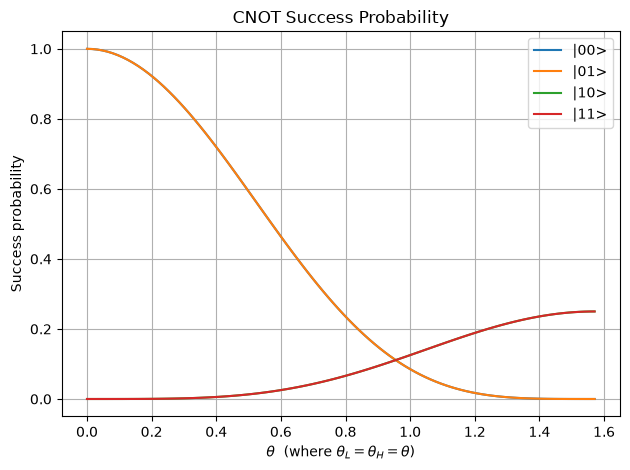

In [ ]:
theta_values = np.linspace(0, np.pi/2, 100)

success = {
    "|00>": [],
    "|01>": [],
    "|10>": [],
    "|11>": []
}

for theta in theta_values:

    params = (
        theta, 0.0,
        THETA_PI4, 0.0,
        theta, 0.0,
        theta, 0.0,
        THETA_PI4, np.pi
    )

    for name, input_state in inputs.items():
        result = ralph_cnot(input_state, *params)
        p = result.state.all_fock_probs()
        success[name].append(p[desired_outputs[name]])



plt.plot(theta_values, success["|00>"], label="|00>")
plt.plot(theta_values, success["|01>"], label="|01>")
plt.plot(theta_values, success["|10>"], label="|10>")
plt.plot(theta_values, success["|11>"], label="|11>")

plt.xlabel(r"$\theta$  (where $\theta_L=\theta_H=\theta$)")
plt.ylabel("Success probability")
plt.title("CNOT Success Probability")

plt.grid(True)
plt.legend()
plt.show()